In [1]:
import os, sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
def vanDerPoll(X, t, epsilon):
    x = X[0]
    y = X[1]
    dxdt = y
    dydt = epsilon*(1-x*x)*y - x
    return [dxdt, dydt]
vdpX0 = [0, 1.5]
vdpParams = [0.2]

In [3]:
model = ChebyKAN([2, 10, 2], 4)
kanODE = KANODE(model, vanDerPoll, vdpX0, vdpParams, 50, 20, 150)

100%|██████████| 10000/10000 [13:22:43<00:00,  4.82s/it] 


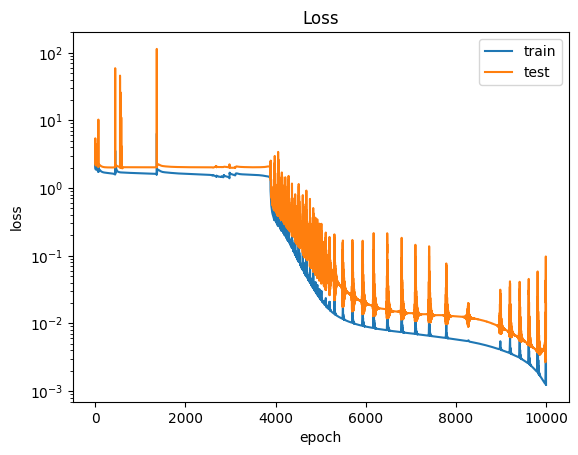

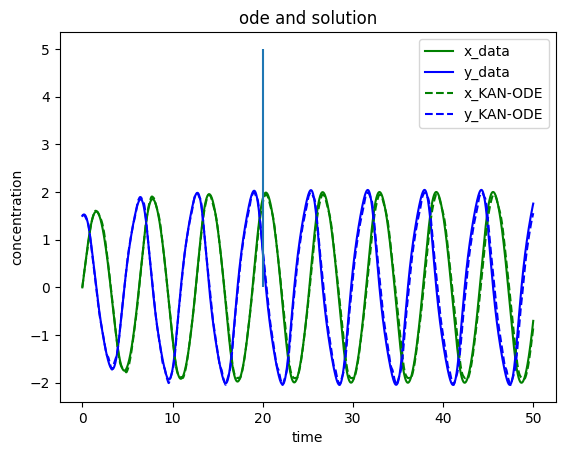

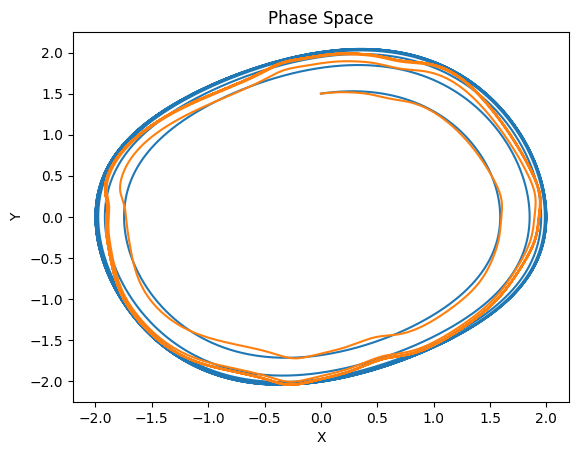

In [ ]:
saveDirectory = os.path.join(module_path, "savedModels", "vdp")
kanODE.train(-1, saveDirectory=saveDirectory)
_, solution = kanODE.test()
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])